# Most probable path according to the background

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from utils_mean_field import *
from script_mean_field_covid import *
# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "covid/")

from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
ab_names=list(ESCAPE_VECTORS.keys())


e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# Order params

In [2]:
# # Your extract_parameters function
# def extract_parameters(path):
#     beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
#     D_match = re.search(r'D_(\d+)', path)
#     ab_parts = path.split('_')
#     condition = ab_parts[-1]
#     return {
#         "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
#         "D": int(D_match.group(1)) if D_match else None,
#         "condition": condition
#     }

# # Get all folders
# all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

# paths = []
# labels = []
# SELECTED_CONDITIONS=['WT','Alpha','Delta', 'BA1']
# for d in all_dirs:
#     params = extract_parameters(d)
#     if (
#         params["beta_ab"] == BETA_AB and
#         params["D"] == D and
#         params["condition"] in SELECTED_CONDITIONS
#     ):
#         paths.append(d)
#         labels.append(params["condition"])

# Project

## Gisaid

In [3]:
VOCS=Proteins_utils.load_FASTA("../covid/gisaid/sequences_vocs.fasta", drop_duplicates=False)
VOCS = VOCS[:,BEGIN:-END]
def extract_voc_names_from_fasta(fasta_path):
    """
    Extracts VOC names from a FASTA file.
    Assumes each entry starts with a '>' followed by the VOC name.
    """
    voc_names = []
    with open(fasta_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                voc_name = line[1:].strip()
                voc_names.append(voc_name)
    return voc_names
# List of VOCs to keep
KEEP = {"BA.5", "XBB", "BQ.1.1", "WT"}

# Extract all VOC names
VOC_NAMES = extract_voc_names_from_fasta("../covid/gisaid/sequences_vocs.fasta")

# Build mask for selected VOCs
mask = [any(name.startswith(k) for k in KEEP) for name in VOC_NAMES]

# Apply mask to names and sequences
VOC_NAMES = [name for name, keep in zip(VOC_NAMES, mask) if keep]
VOCS = VOCS[mask,:]





In [4]:
rbd_dates = pd.read_csv('../covid/gisaid/rbd_df.csv')
print(rbd_dates.shape)
rbd_dates

(32543, 4)


,sequence,count,date_of_100th,q05_date
0,SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,2817840,2020-01-01,2021-06-28
1,SVYAWNRKRISNCVADYSVLYNFAPFFAFKCYGVSPTKLNDLCFTN...,876875,2021-12-17,2022-02-03
2,SVYAWNRKRISNCVADYSVLYNLAPFFTFKCYGVSPTKLNDLCFTN...,812034,2020-01-01,2021-12-23
3,SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,763168,2020-01-01,2020-03-29
4,SVYAWNRKRISNCVADYSVLYNFAPFFAFKCYGVSPTKLNDLCFTN...,682766,2022-02-08,2022-06-12
...,...,...,...,...
32538,SVYAWNRKRISNCVADYSDLYNSASFSTFKCYGVSPTKLNDLCFTN...,1,NaN,2021-12-16
32539,SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,1,NaN,2022-03-02
32540,SVYAWNRKRISNCVADYSVLYNLAPFFTFKCYGVSPTKLNDLCFTN...,1,NaN,2022-02-17
32541,SVYAWNRKRISNCVADYSVLYNLAPFFTFKCYGVSPTKLNDLCFTN...,1,NaN,2022-02-09


In [5]:
# Define the output filename
output_file = "../covid/gisaid/sequences_rbd_df.fasta"

# Open the file for writing
with open(output_file, "w") as f:
    for index, row in rbd_dates.iterrows():
        # Create a header. 
        # It is best practice to include a unique ID (index) and the metadata.
        # Format: >unique_id|count|date|q05_date
        header = f">seq_{index}|count={row['count']}|date={row['date_of_100th']}|q05={row['q05_date']}"
        
        # Get the sequence
        sequence = row['sequence']
        
        # Write to file (header + newline + sequence + newline)
        f.write(f"{header}\n{sequence}\n")

print(f"Successfully created {output_file} with {len(rbd_dates)} sequences.")

rbd_dates['q05_date'] = pd.to_datetime(rbd_dates['q05_date'])
seqs=Proteins_utils.load_FASTA('../covid/gisaid/sequences_rbd_df.fasta', drop_duplicates=False)
seqs.shape


Successfully created ../covid/gisaid/sequences_rbd_df.fasta with 32543 sequences.


(32543, 178)

In [6]:
# #filter on count>=10
# index_count10=rbd_dates[rbd_dates['count']>=10].index
# rbd_dates=rbd_dates.loc[index_count10]
# seqs=seqs[index_count10,:]

In [7]:
one_hot_seqs=np.array([one_hot_encode_concat(seq) for seq in seqs])
# get indexes of 'count' >1
indexes = rbd_dates[rbd_dates['count'] >= 100].index
rbd_dates = rbd_dates.iloc[indexes]
print("rbd_dates", rbd_dates.shape)
one_hot_seqs = one_hot_seqs[indexes]
one_hot_seqs.shape

rbd_dates (1052, 4)


(1052, 3560)

In [8]:
seqs.shape

(32543, 178)

In [9]:
rbd_dates

,sequence,count,date_of_100th,q05_date
0,SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,2817840,2020-01-01,2021-06-28
1,SVYAWNRKRISNCVADYSVLYNFAPFFAFKCYGVSPTKLNDLCFTN...,876875,2021-12-17,2022-02-03
2,SVYAWNRKRISNCVADYSVLYNLAPFFTFKCYGVSPTKLNDLCFTN...,812034,2020-01-01,2021-12-23
3,SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,763168,2020-01-01,2020-03-29
4,SVYAWNRKRISNCVADYSVLYNFAPFFAFKCYGVSPTKLNDLCFTN...,682766,2022-02-08,2022-06-12
...,...,...,...,...
1047,SVYAWNRKRIGNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,100,2022-02-02,2021-08-06
1048,SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,100,2022-01-24,2020-04-02
1049,SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,100,2023-04-13,2022-10-31
1050,SVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTN...,100,2022-01-12,2021-07-20


In [10]:
wt_idx  = [i for i, n in enumerate(VOC_NAMES) if str(n).startswith("WT")]


wt_seq  = VOCS[wt_idx[0], :]   # 1D row for WT
L=178

In [11]:
folder='results_scripts/covid_D_20/mean_f_free_ab_beta_ab_10_D_1'
# folder='results_scripts/mean_f_free_ab_beta_ab_0.2_D_21_ab_class1_2'
mopt = np.load(f"{folder}/mopt.npy") [:,:29]
# folder0='results_scripts/covid_D_20/mean_f_free_ab_beta_ab_0_D_1'
# mopt0 = np.load(f"{folder0}/mopt.npy") [:,:29]
# folderba1='results_scripts/covid_D_20_ba1/ba1_mean_f_free_ab_beta_ab_10_D_1'
# moptba1 = np.load(f"{folderba1}/mopt.npy") [:,:29]
mopt.shape


(21, 29)

In [12]:
ab_names = list(ESCAPE_VECTORS.keys())
L=178
wab = np.zeros((L, 20, len(ab_names)))
for idx, ab in enumerate(ab_names):
    w_ab = ESCAPE_VECTORS[ab].reshape(L, 20)  # "no bias"
    wab[:, :, idx] = w_ab
#put last dimension first
wab = np.moveaxis(wab, -1, 0)
print("wab shape", wab.shape)
wgamma_flat= wab.reshape(wab.shape[0], -1)

wgamma_flat.min()

wab shape (29, 178, 20)


-4.605170185988091

In [13]:
def project_without_blas(one_hot_seqs, wgamma_flat):
    """
    Project each of N sequences (length-D) onto each of K axes,
    without calling the BLAS-backed dot() function.
    Returns an (N, K) array of projections.
    """
    N, D = one_hot_seqs.shape
    K, D2 = wgamma_flat.shape

    assert D == D2
    
    # pre-allocate output
    projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
    # for each axis, multiply elementwise and sum
    for k in range(K):
        # Broadcast: (N, D) * (D,) → (N, D), then sum over D → (N,)
        projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
    return projections


In [14]:
def get_mcmc_proba_aa(dir,wgamma_flat):
    paths_nb=100
    print("beta_w", beta_w)
    proj_mat=[]
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        one_hot_seqs = np.array([one_hot_encode_concat(seq) for seq in sequences])
        projs= project_without_blas(one_hot_seqs, wgamma_flat)
        proj_mat.append(projs)
    proj_mat= np.array(proj_mat)
    #mean around axis 0
    print("proj_mat", proj_mat.shape)
    return proj_mat
beta_w=10
dir_mcmc = f"../covid/paths/test_covid_T20_beta_ab_{beta_w}/"
paths_mcmc=get_mcmc_proba_aa(dir_mcmc, wgamma_flat)


beta_w 10
proj_mat (100, 21, 29)


[[-0.17808906 -0.17808906 -0.17808906 ... -3.91318646 -0.21743247
  -0.2538409 ]
 [-0.4508531  -0.23748633 -0.17808906 ... -3.71687805 -0.44589078
  -0.71461628]
 [-0.4508531  -0.23748633 -0.17808906 ... -3.71318991 -0.44856089
  -0.7165565 ]
 ...
 [-0.42503723 -0.17808906 -0.17808906 ... -7.33147371 -0.43095416
  -0.65250589]
 [-0.17808906 -0.17808906 -0.17808906 ... -3.9524248  -0.23598183
  -0.2882189 ]
 [-0.4508531  -0.17808906 -0.17808906 ... -3.48423477 -0.33268288
  -0.46248457]]


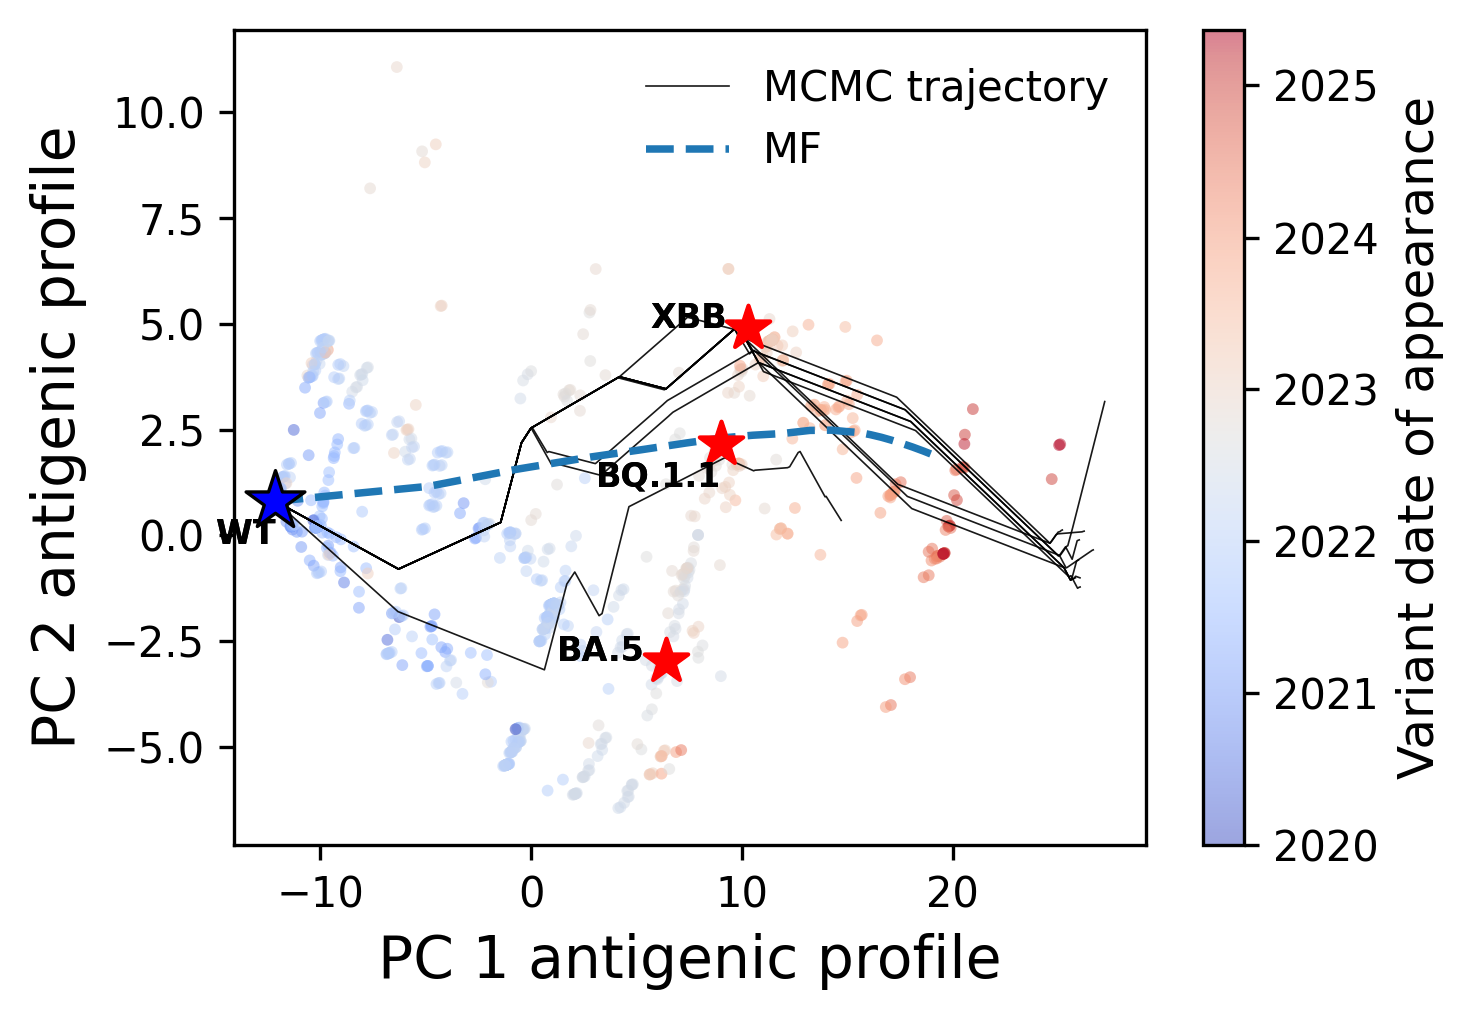

In [16]:
def project_and_plot_2d(one_hot_seqs, wgamma_flat, dates_series):
    """
    Projects N×D sequences onto K antibody axes (wgamma_flat K×D),
    PCA to 2D, colors points by average escape = mean(projection),
    overlays WT/BA1 stars and MF trajectories (mopt, moptba1) on same plot.
    Expects wt_seq, ba1_seq, mopt, moptba1 in scope.
    """
    # 1) projections and average escape
    projections = project_without_blas(one_hot_seqs, wgamma_flat)   # (N,K)
    print (projections)

    # 2) PCA to 2D
    pca = PCA(n_components=2).fit(projections)
    X_2d = pca.transform(projections)

    # 3) WT and BA1 stars only
    wt_proj  = project_without_blas(np.array([one_hot_encode_concat(wt_seq)]),  wgamma_flat)  # (1,K)
    # ba1_proj = project_without_blas(np.array([one_hot_encode_concat(ba1_seq)]), wgamma_flat)  # (1,K)
    wt_2d  = pca.transform(wt_proj)   # (1,2)
    # ba1_2d = pca.transform(ba1_proj)  # (1,2)

    vocs_proj= project_without_blas(np.array([one_hot_encode_concat(voc) for voc in VOCS]), wgamma_flat)
    vocs_2d = pca.transform(vocs_proj)  # shape: (N, 2)

    # 4) MF trajectories (use same PCA space)
    mopt_2d    = pca.transform(mopt)     # (T,2)
    # moptba1_2d = pca.transform(moptba1)  # (T,2)

    # 5) plot
    fig, ax = plt.subplots(figsize=(5., 3.5), dpi=300)

       # 1) make sure you convert your Series to plain Python datetimes
    dates = pd.to_datetime(dates_series)
    np_dates = dates.values.astype("datetime64[us]")
    mdates_num = mdates.date2num(np_dates)


# 3) set up a true Normalize object
    norm = Normalize(vmin=mdates_num.min(), vmax=mdates_num.max())
    sc = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=mdates_num,
        cmap='coolwarm',
        s=8,
        edgecolors='none',
        alpha=0.5,
        
    )

    for i, (x, y) in enumerate(vocs_2d):
        ax.scatter(x, y, color='red', marker='*', s=100)
        #boldly annotate each point with the corresponding VOC name
        ax.annotate(VOC_NAMES[i], (x+(i%2-1)*1, y+((i+1)%2-1)*1), fontsize=8,#bold 
        fontweight='bold', color='black', ha='right')

    import matplotlib as mpl
    import matplotlib.patheffects as pe

    use_tex = mpl.rcParams.get("text.usetex", False)

    for i, (x, y) in enumerate(vocs_2d):
        ax.scatter(x, y, color='red', marker='*', s=120, zorder=3)

        label = VOC_NAMES[i]
        #replace BA1 with BA.1
        label = label.replace("BA1", "BA.1")
        if use_tex:
            # Escape underscores etc. if needed:
            label_tex = r'\textbf{' + label.replace('_', r'\_') + '}'
            ax.annotate(label_tex, (x + (i%2-1)*1, y + ((i+1)%2-1)*1),
                        fontsize=8, color='black', ha='right', zorder=4)
        else:
            ax.annotate(label, (x + (i%2-1)*1, y + ((i+1)%2-1)*1),
                        fontsize=8, fontweight='bold', color='black',
                        ha='right', zorder=4)


   
    ax.scatter(wt_2d[0,0],  wt_2d[0,1],  color="blue", marker="*", s=220,
           edgecolors="black", linewidths=0.8, zorder=10)
    # ax.scatter(ba1_2d[0,0], ba1_2d[0,1], color="blue", marker="*", s=220,
    #        edgecolors="black", linewidths=0.8, zorder=10)
    
    import random
    random.seed(1)  # for reproducibility
    random_idxs = random.sample(range(len(paths_mcmc)), 10)
    paths_mcmc_2d = [pca.transform(paths_mcmc[i]) for i in random_idxs]
    for i, path in enumerate(paths_mcmc_2d):
        label = "MCMC trajectory" if i == 0 else None
        ax.plot(path[:, 0], path[:, 1],
                color='black', linewidth=0.4, alpha=0.9,
                label=label)
    # ax.annotate('WT', (wt_2d[0, 0],  wt_2d[0, 1]+0.5), fontsize=10,#bold 
    #     fontweight='black', color='black', ha='right')
 

    # MF trajectories
    ax.plot(mopt_2d[:, 0],    mopt_2d[:, 1],    color="tab:blue", ls="--", lw=1.8, label="MF")
    # ax.plot(moptba1_2d[:, 0], moptba1_2d[:, 1], color="tab:red",  ls="--", lw=1.8, label="MF start BA.1")

    # labels and frame
    ax.set_xlabel("PC 1 antigenic profile", fontsize=14)
    ax.set_ylabel("PC 2 antigenic profile", fontsize=14)
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    # colorbar for average escape
    cbar = fig.colorbar(sc, ax=ax, orientation='vertical')
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    cbar.ax.yaxis_date()
    cbar.ax.yaxis.set_major_locator(locator)
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label("Variant date of appearance", fontsize=12)

    ax.legend(frameon=False, fontsize=10, loc="best")
    plt.tight_layout()
    plt.show()

# call:
project_and_plot_2d(one_hot_seqs, wgamma_flat, rbd_dates['q05_date'])
